# FABLE Block Encoding for the Linear Pendulum

This notebook implements the FABLE method for block-encoding the
forward-Euler update matrix of the linear pendulum.

In the previous notebooks, block encoding was constructed in two ways:

1. by explicitly constructing a unitary dilation of the matrix, and
2. by using a naive matrix-entry oracle containing one multi-controlled
   $R_y$ rotation for each matrix entry.

The naive oracle makes the matrix-entry mechanism transparent, but its
multi-controlled rotations become expensive when decomposed into elementary
gates. FABLE replaces these multi-controlled rotations with a uniformly
controlled rotation circuit consisting only of ordinary $R_y$ rotations
and CNOT gates.

For a real $N\times N$ matrix $A$, with $N=2^n,$ the entries are first scaled as

$$
B=\frac{A}{\alpha},
$$

so that $|B_{ij}|\leq 1$.

The matrix-entry oracle must implement

$$
O_B|0\rangle_a|i\rangle|j\rangle
=\left(
B_{ij}|0\rangle_a
+
\sqrt{1-B_{ij}^2}|1\rangle_a
\right)
|i\rangle|j\rangle.
$$

FABLE realizes this oracle by transforming the entry-dependent rotation
angles using a Walsh-Hadamard transformation combined with a Gray-code
permutation. The transformed angles are applied sequentially to the entry
ancilla, with CNOT gates producing the required sign patterns.

For the $2\times2$ case considered here, FABLE uses

- one entry ancilla,
- one row qubit,
- one column/system qubit,
- four ordinary $R_y$ rotations, and
- four CNOT gates.

The complete construction encodes

$$
\frac{B}{2}
=\frac{A}{2\alpha}.
$$

The goals of this notebook are to:

1. calculate the transformed FABLE angles;
2. construct the uniformly controlled rotation circuit;
3. verify the matrix-entry oracle for every row-column bitstring;
4. extract and verify the encoded block;
5. apply the block encoding to the linear-pendulum update matrix;
6. recover one Euler step using exact statevector extraction;
7. reproduce the complete Euler trajectory; and
8. compare the circuit structure with the naive-oracle construction.

No rotation-angle threshold is used in this notebook. Therefore, the
implemented FABLE circuit is an exact block encoding up to floating-point
precision. Approximation enters FABLE only when small transformed rotations
are deliberately removed to compress the circuit.

## Imports

NumPy is used for matrix operations and angle transformations, while Qiskit
is used to construct and verify the quantum circuits.

`Statevector` provides exact output amplitudes for the trajectory
calculation, and `Operator` is used to extract the encoded matrix block from
the full circuit unitary.

This notebook focuses on real matrices. Consequently, only $R_y$ rotations
are needed. The general FABLE construction for complex matrices additionally
requires rotations that encode the phases of the matrix entries.

In [2]:
import numpy as np
import matplotlib.pyplot as plt

from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector, Operator

## Qubit-Index Convention

For a $2\times2$ matrix, the circuit uses three qubits:

$$
q_0=\text{entry-loading ancilla},
$$

$$
q_1=\text{row register},
$$

$$
q_2=\text{column/system register}.
$$

The matrix-entry oracle acts as

$$
|0\rangle_{q_0}|i\rangle_{q_1}|j\rangle_{q_2}
\longmapsto
\left(
B_{ij}|0\rangle_{q_0}
+
\sqrt{1-B_{ij}^2}|1\rangle_{q_0}
\right)
|i\rangle_{q_1}|j\rangle_{q_2}.
$$

Qiskit uses little-endian statevector ordering. Therefore, the displayed
three-qubit basis is

$$
|q_2q_1q_0\rangle,
$$

and the integer index corresponding to a bitstring is

$$
\operatorname{index}
=q_0+2q_1+4q_2.
$$

The helper function below is used whenever amplitudes or unitary matrix
elements are extracted.

In [3]:
def basis_index(q0, q1, q2):
    return q0 + 2*q1 + 4*q2

## Scale matrix entries

The entry-loading oracle encodes each matrix element through an ancilla
rotation. For a real scaled entry $B_{ij}$, define

$$
\phi_{ij}=2\arccos(B_{ij}).
$$

Then

$$
R_y(\phi_{ij})|0\rangle
=B_{ij}|0\rangle
+
\sqrt{1-B_{ij}^2}|1\rangle.
$$

This relation requires
$
|B_{ij}|\leq1.
$

We therefore scale the original matrix $A$ as

$$
B=\frac{A}{\alpha},
$$

where
$
\alpha\geq\max_{i,j}|A_{ij}|.
$

If no value is supplied, the code chooses
$
\alpha=\max_{i,j}|A_{ij}|.
$

This differs from the spectral-norm scaling used in the manual unitary
dilation. FABLE directly encodes individual matrix entries, so the relevant
requirement is an entrywise bound.

The complete $2\times2$ FABLE circuit encodes

$$
\frac{B}{2}
=\frac{A}{2\alpha}.
$$

Thus, although `alpha` denotes the entry-scaling factor in the code, the
total subnormalization factor of the extracted block relative to $A$ is
$
2\alpha.
$

In [4]:
def scale_matrix_entries(A, alpha=None):
    A = np.asarray(A, dtype=float)

    max_abs_entry = np.max(np.abs(A))

    if max_abs_entry == 0:
        alpha = 1.0 if alpha is None else alpha
        return A / alpha, alpha

    if alpha is None:
        alpha = max_abs_entry

    if alpha < max_abs_entry - 1e-12:
        raise ValueError(
            "alpha must be at least max(abs(A_ij))."
        )

    B = A / alpha

    if np.max(np.abs(B)) > 1 + 1e-12:
        raise ValueError(
            "Scaled matrix has entries outside [-1, 1]."
        )

    return B, alpha

## Calculating tranformed angles

For the scaled matrix

$$
B=
\begin{pmatrix}
B_{00}&B_{01}\\
B_{10}&B_{11}
\end{pmatrix},
$$

the required entry-dependent rotations are

$$
\boldsymbol{\phi}
=
\begin{pmatrix}
\phi_{00}\\
\phi_{01}\\
\phi_{10}\\
\phi_{11}
\end{pmatrix}
=2
\begin{pmatrix}
\arccos(B_{00})\\
\arccos(B_{01})\\
\arccos(B_{10})\\
\arccos(B_{11})
\end{pmatrix}.
$$

The entries are flattened in row-major order:

$$
(B_{00},B_{01},B_{10},B_{11}).
$$

The naive oracle would apply each $\phi_{ij}$ using a separate
multi-controlled rotation. FABLE instead transforms the complete vector of
four entry angles into four circuit angles:

$$
\widehat{\boldsymbol{\phi}}
=\begin{pmatrix}
\widehat{\phi}_0\\
\widehat{\phi}_1\\
\widehat{\phi}_2\\
\widehat{\phi}_3
\end{pmatrix}.
$$

For the cyclic Gray-code sequence used here, the required and transformed
angles satisfy

$$
\boldsymbol{\phi}
=W_G\widehat{\boldsymbol{\phi}},
$$

where

$$
W_G=
\begin{pmatrix}
1&1&1&1\\
1&-1&-1&1\\
1&1&-1&-1\\
1&-1&1&-1
\end{pmatrix}.
$$

The columns of $W_G$ are orthogonal:
$
W_G^T W_G=4I.
$

Therefore,

$$
W_G^{-1}=\frac14 W_G^T,
$$

and the transformed circuit angles are

$$
\widehat{\boldsymbol{\phi}}
=\frac14W_G^T\boldsymbol{\phi}.
$$

Explicitly,

$$
\widehat{\phi}_0
=\frac14
\left(
\phi_{00}+\phi_{01}+\phi_{10}+\phi_{11}
\right),
$$

$$
\widehat{\phi}_1
=\frac14
\left(
\phi_{00}-\phi_{01}+\phi_{10}-\phi_{11}
\right),
$$

$$
\widehat{\phi}_2
=\frac14
\left(
\phi_{00}-\phi_{01}-\phi_{10}+\phi_{11}
\right),
$$

and

$$
\widehat{\phi}_3
=\frac14
\left(
\phi_{00}+\phi_{01}-\phi_{10}-\phi_{11}
\right).
$$

All four entry angles are therefore transformed together. The resulting
four transformed angles are then each used once in a single shared FABLE
oracle.

In [5]:
def calculate_fable_angles_2x2(B):
    B = np.asarray(B, dtype=float)

    if B.shape != (2, 2):
        raise ValueError(
            "This function currently supports only 2x2 matrices."
        )

    if np.max(np.abs(B)) > 1 + 1e-12:
        raise ValueError(
            "All entries of B must lie in [-1, 1]."
        )

    # Matrix entries in the order:
    # (B00, B01, B10, B11).
    entries = B.reshape(-1, order="C")
    entries = np.clip(entries, -1.0, 1.0)

    # Net physical rotations required for each control state.
    entry_angles = 2.0 * np.arccos(entries)

    # Sign matrix generated by the cyclic Gray-code circuit.
    W_gray = np.array([
        [1,  1,  1,  1],
        [1, -1, -1,  1],
        [1,  1, -1, -1],
        [1, -1,  1, -1]
    ], dtype=float)

    # Since W_gray.T @ W_gray = 4I,
    # W_gray^{-1} = W_gray.T / 4.
    transformed_angles = W_gray.T @ entry_angles / 4.0

    return entry_angles, transformed_angles

## Testing angle transformation

Before constructing the quantum circuit, we verify the classical angle
transformation using

$$
B_{\mathrm{test}}
=\begin{pmatrix}
0.6&0.2\\
-0.3&0.8
\end{pmatrix}.
$$

The code first calculates the required entry-angle vector
$\boldsymbol{\phi}$, transforms it into
$\widehat{\boldsymbol{\phi}}$, and reconstructs the original angles
through

$$
\boldsymbol{\phi}_{\mathrm{reconstructed}}
=W_G\widehat{\boldsymbol{\phi}}.
$$

The reconstruction error

$$
\left\|
\boldsymbol{\phi}_{\mathrm{reconstructed}}
-\boldsymbol{\phi}
\right\|_2
$$

is approximately $4.4\times10^{-16}$. This confirms that the angle
ordering and Gray-code sign matrix are consistent up to floating-point
precision.

In [6]:
B_test = np.array([
    [0.6,  0.2],
    [-0.3, 0.8]
], dtype=float)

entry_angles, transformed_angles = calculate_fable_angles_2x2(
    B_test
)

W_gray = np.array([
    [1,  1,  1,  1],
    [1, -1, -1,  1],
    [1,  1, -1, -1],
    [1, -1,  1, -1]
], dtype=float)

reconstructed_angles = W_gray @ transformed_angles

print("Required entry angles:")
print(entry_angles)

print("\nTransformed FABLE angles:")
print(transformed_angles)

print("\nReconstructed entry angles:")
print(reconstructed_angles)

print("\nAngle-transformation error:")
print(np.linalg.norm(reconstructed_angles - entry_angles))

Required entry angles:
[1.85459044 2.73887681 3.75097796 1.28700222]

Transformed FABLE angles:
[ 2.40786186  0.39492234 -0.83706553 -0.11112823]

Reconstructed entry angles:
[1.85459044 2.73887681 3.75097796 1.28700222]

Angle-transformation error:
4.440892098500626e-16


## Uniformly controlled FABLE oracle

The transformed angles are implemented using a cyclic Gray-code circuit.
For the control register $|ij\rangle$, the Gray-code path is

$$
00\longrightarrow01\longrightarrow11
\longrightarrow10\longrightarrow00.
$$

Only one control bit changes at each transition. The corresponding CNOT
controls are

$$
\text{column},\quad
\text{row},\quad
\text{column},\quad
\text{row}.
$$

All rotations act on the entry ancilla $q_0$, which is also the target of
every CNOT.

The circuit sequence is

$$
R_y(\widehat{\phi}_0)
\rightarrow CX_{\mathrm{col},a}
\rightarrow R_y(\widehat{\phi}_1)
\rightarrow CX_{\mathrm{row},a}
$$

$$
\rightarrow R_y(\widehat{\phi}_2)
\rightarrow CX_{\mathrm{col},a}
\rightarrow R_y(\widehat{\phi}_3)
\rightarrow CX_{\mathrm{row},a}.
$$

The final CNOT closes the Gray-code cycle. Without it, a residual
control-dependent $X$ operation would remain on the ancilla.

The construction follows from

$$
X R_y(\theta)X=R_y(-\theta)
$$

and

$$
R_y(\theta_1)R_y(\theta_2)
=R_y(\theta_1+\theta_2).
$$

For a fixed control state $|ij\rangle$, the CNOTs change the signs of
selected transformed rotations. The effective ancilla angle becomes

$$
\phi_{ij}
=\widehat{\phi}_0
+
(-1)^j\widehat{\phi}_1
+
(-1)^{i\oplus j}\widehat{\phi}_2
+
(-1)^i\widehat{\phi}_3.
$$

The four cases are

$$
\begin{aligned}
\phi_{00}
&=
\widehat{\phi}_0+\widehat{\phi}_1
+\widehat{\phi}_2+\widehat{\phi}_3,\\
\phi_{01}
&=
\widehat{\phi}_0-\widehat{\phi}_1
-\widehat{\phi}_2+\widehat{\phi}_3,\\
\phi_{10}
&=
\widehat{\phi}_0+\widehat{\phi}_1
-\widehat{\phi}_2-\widehat{\phi}_3,\\
\phi_{11}
&=
\widehat{\phi}_0-\widehat{\phi}_1
+\widehat{\phi}_2-\widehat{\phi}_3.
\end{aligned}
$$

Thus, the four transformed rotations are applied once in one shared
circuit. Each row-column branch experiences a different signed combination,
giving the required entry-dependent rotation.

In [7]:
def apply_fable_entry_oracle_2x2(
    qc,
    transformed_angles,
    ancilla=0,
    row=1,
    col=2
):
    transformed_angles = np.asarray(
        transformed_angles,
        dtype=float
    )

    if transformed_angles.shape != (4,):
        raise ValueError(
            "Exactly four transformed angles are required."
        )

    # First transformed rotation.
    qc.ry(transformed_angles[0], ancilla)

    # Gray-code transition: 00 -> 01.
    qc.cx(col, ancilla)

    # Second transformed rotation.
    qc.ry(transformed_angles[1], ancilla)

    # Gray-code transition: 01 -> 11.
    qc.cx(row, ancilla)

    # Third transformed rotation.
    qc.ry(transformed_angles[2], ancilla)

    # Gray-code transition: 11 -> 10.
    qc.cx(col, ancilla)

    # Fourth transformed rotation.
    qc.ry(transformed_angles[3], ancilla)

    # Gray-code transition: 10 -> 00.
    # This closes the cyclic sequence.
    qc.cx(row, ancilla)

In [8]:
def create_fable_entry_oracle_circuit_2x2(B):
    entry_angles, transformed_angles = (
        calculate_fable_angles_2x2(B)
    )

    qc = QuantumCircuit(3)

    apply_fable_entry_oracle_2x2(
        qc,
        transformed_angles,
        ancilla=0,
        row=1,
        col=2
    )

    return qc, entry_angles, transformed_angles

## Display FABLE circuit

The displayed oracle contains four ordinary $R_y$ rotations and four
CNOT gates. No multi-controlled rotations are used.

The numerical matrix data are distributed among all four transformed
angles. Therefore, an individual transformed angle generally does not
correspond to a single matrix entry. Instead, each entry is reconstructed
from a signed combination of all four transformed angles.

This is the central difference between the naive and FABLE oracle
implementations:

- in the naive oracle, each entry selects one multi-controlled rotation;
- in FABLE, every control branch passes through the same sequence of
  rotations and CNOTs, but experiences a different effective signed sum.

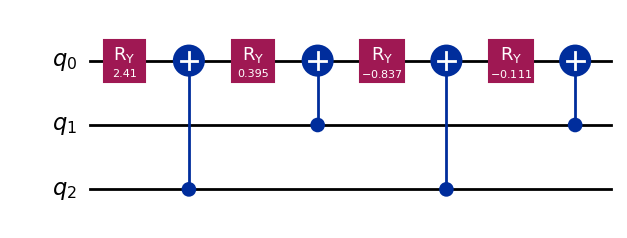

In [9]:
qc_oracle, entry_angles, transformed_angles = (
    create_fable_entry_oracle_circuit_2x2(B_test)
)

display(qc_oracle.draw("mpl"))

## Verify the oracle for all matrix entries

To verify the entry oracle independently of the complete block-encoding
circuit, each row-column basis state is tested separately.

For each pair

$$
(i,j)\in\{(0,0),(0,1),(1,0),(1,1)\},
$$

we prepare

$$
|0\rangle_{q_0}|i\rangle_{q_1}|j\rangle_{q_2}
$$

and apply the FABLE oracle. The expected result is

$$
O_B|0\rangle|i\rangle|j\rangle
=\left(
B_{ij}|0\rangle
+
\sqrt{1-B_{ij}^2}|1\rangle
\right)|i\rangle|j\rangle.
$$

The two amplitudes extracted for each control bitstring should therefore be

$$
\langle0,i,j|O_B|0,i,j\rangle=B_{ij}
$$

and

$$
\langle1,i,j|O_B|0,i,j\rangle
=\sqrt{1-B_{ij}^2}.
$$

Because the transformed rotations and CNOTs do not change the row and column
registers, amplitudes remain within the selected $|ij\rangle$ subspace.

In [10]:
def test_fable_oracle_entries_2x2(B):
    B = np.asarray(B, dtype=float)

    results = {}

    for i in [0, 1]:
        for j in [0, 1]:
            qc = QuantumCircuit(3)

            # Prepare the selected row state |i> on q1.
            if i == 1:
                qc.x(1)

            # Prepare the selected column state |j> on q2.
            if j == 1:
                qc.x(2)

            _, transformed_angles = (
                calculate_fable_angles_2x2(B)
            )

            apply_fable_entry_oracle_2x2(
                qc,
                transformed_angles,
                ancilla=0,
                row=1,
                col=2
            )

            state = Statevector.from_instruction(qc).data

            # Amplitude with ancilla q0 = 0.
            amplitude_0 = state[
                basis_index(q0=0, q1=i, q2=j)
            ]

            # Amplitude with ancilla q0 = 1.
            amplitude_1 = state[
                basis_index(q0=1, q1=i, q2=j)
            ]

            results[(i, j)] = {
                "target_entry": B[i, j],
                "ancilla_0_amplitude": amplitude_0,
                "expected_ancilla_1": np.sqrt(
                    1.0 - B[i, j]**2
                ),
                "ancilla_1_amplitude": amplitude_1
            }

    return results

In [11]:
oracle_results = test_fable_oracle_entries_2x2(B_test)

for (i, j), result in oracle_results.items():
    print(f"Entry ({i}, {j})")
    print("Target B_ij =", result["target_entry"])
    print(
        "Ancilla |0> amplitude =",
        np.real_if_close(
            result["ancilla_0_amplitude"]
        )
    )
    print(
        "Ancilla |1> amplitude =",
        np.real_if_close(
            result["ancilla_1_amplitude"]
        )
    )
    print(
        "Expected |1> amplitude =",
        result["expected_ancilla_1"]
    )
    print()

Entry (0, 0)
Target B_ij = 0.6
Ancilla |0> amplitude = 0.6
Ancilla |1> amplitude = 0.8
Expected |1> amplitude = 0.8

Entry (0, 1)
Target B_ij = 0.2
Ancilla |0> amplitude = 0.20000000000000004
Ancilla |1> amplitude = 0.9797958971132712
Expected |1> amplitude = 0.9797958971132712

Entry (1, 0)
Target B_ij = -0.3
Ancilla |0> amplitude = -0.3
Ancilla |1> amplitude = 0.9539392014169455
Expected |1> amplitude = 0.9539392014169457

Entry (1, 1)
Target B_ij = 0.8
Ancilla |0> amplitude = 0.8000000000000002
Ancilla |1> amplitude = 0.5999999999999999
Expected |1> amplitude = 0.5999999999999999



All four $|0\rangle$-ancilla amplitudes reproduce the corresponding
matrix entries. This includes the negative entry
$
B_{10}=-0.3,
$
which is encoded directly as a negative amplitude.

The $|1\rangle$-ancilla amplitudes also agree with
$
\sqrt{1-B_{ij}^2}.
$

This confirms that the transformed-angle circuit implements the same
matrix-entry oracle as the naive collection of multi-controlled rotations.

## Compute single oracle error

The oracle error is defined here as the maximum absolute difference between
a target matrix entry and the corresponding extracted ancilla amplitude:

$$
\epsilon_{\mathrm{oracle}}
=\max_{i,j}
\left|
\langle0,i,j|O_B|0,i,j\rangle-B_{ij}
\right|.
$$

In [12]:
max_oracle_error = 0.0

for result in oracle_results.values():
    error = abs(
        result["ancilla_0_amplitude"]
        - result["target_entry"]
    )

    max_oracle_error = max(max_oracle_error, error)

print(
    "Maximum matrix-entry encoding error:",
    max_oracle_error
)

Maximum matrix-entry encoding error: 1.1102230246251565e-16


## Complete FABLE block encoding circuit

The matrix-entry oracle alone loads the individual values $B_{ij}$, but it
does not yet apply the matrix $B$ to an input vector.

The complete FABLE block-encoding circuit uses the same outer structure as
the naive-oracle construction:

1. apply a Hadamard gate to the row register;
2. apply the FABLE matrix-entry oracle;
3. swap the row and column registers;
4. apply a second Hadamard gate to the row register; and
5. post-select the entry ancilla and row register in $|0\rangle$.

For an input state

$$
|\psi\rangle
=\sum_{j=0}^{1}\psi_j|j\rangle,
$$

the initial three-qubit state is

$$
|0\rangle_a|0\rangle_{\mathrm{row}}|\psi\rangle_{\mathrm{col}}.
$$

The first Hadamard creates

$$
\frac{1}{\sqrt{2}}
\sum_{i=0}^{1}
|0\rangle_a|i\rangle_{\mathrm{row}}
|\psi\rangle_{\mathrm{col}}.
$$

After the oracle, the ancilla-$|0\rangle$ component is

$$
\frac{1}{\sqrt{2}}
\sum_{i,j}
B_{ij}\psi_j
|0\rangle_a|i\rangle_{\mathrm{row}}|j\rangle_{\mathrm{col}}.
$$

The SWAP exchanges the row and column registers:

$$
\frac{1}{\sqrt{2}}
\sum_{i,j}
B_{ij}\psi_j
|0\rangle_a|j\rangle_{\mathrm{row}}|i\rangle_{\mathrm{col}}.
$$

The second Hadamard followed by post-selection of the row register in
$|0\rangle$ contributes another factor $1/\sqrt{2}$. The successful
branch is therefore

$$
|0\rangle_a|0\rangle_{\mathrm{row}}
\frac{B|\psi\rangle}{2}.
$$

Hence, the extracted block is

$$
\frac{B}{2}
=\frac{A}{2\alpha}.
$$

In [13]:
def create_fable_block_encoding_circuit_2x2(B):
    B = np.asarray(B, dtype=float)

    if B.shape != (2, 2):
        raise ValueError(
            "This function currently supports only 2x2 matrices."
        )

    if np.max(np.abs(B)) > 1 + 1e-12:
        raise ValueError(
            "All entries of B must lie in [-1, 1]."
        )

    ancilla = 0
    row = 1
    col = 2

    # Calculate the FABLE rotation angles.
    entry_angles, transformed_angles = (
        calculate_fable_angles_2x2(B)
    )

    qc = QuantumCircuit(3)

    # Create an equal superposition over the row index.
    qc.h(row)

    # Apply the FABLE matrix-entry oracle.
    apply_fable_entry_oracle_2x2(
        qc,
        transformed_angles,
        ancilla=ancilla,
        row=row,
        col=col
    )

    # Move the output row index to the system register.
    qc.swap(row, col)

    # Project the old column index onto the uniform state.
    qc.h(row)

    return qc

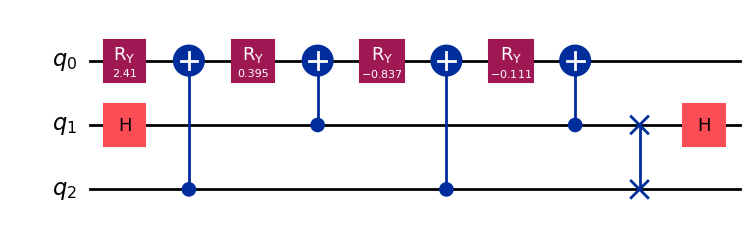

In [14]:
qc_fable_test = create_fable_block_encoding_circuit_2x2(
    B_test
)

display(qc_fable_test.draw("mpl"))

## Extract the encoded block

The successful block is selected by fixing
$
q_0=0,\ q_1=0
$
for both the input and output of the full unitary.

The remaining qubit $q_2$ is the system register. Therefore,

$$
[U_{\mathrm{block}}]_{i,j}
=\langle q_0=0,q_1=0,q_2=i|
U_B
|q_0=0,q_1=0,q_2=j\rangle.
$$

For a correct $2\times2$ FABLE circuit,

$$
U_{\mathrm{block}}=\frac{B}{2}.
$$

The extraction function uses the explicit little-endian basis-index
convention introduced earlier.

In [15]:
def extract_encoded_block_2x2(qc):
    U = Operator(qc).data

    block = np.zeros((2, 2), dtype=complex)

    for out_bit in [0, 1]:
        for in_bit in [0, 1]:
            out_index = basis_index(
                q0=0,
                q1=0,
                q2=out_bit
            )

            in_index = basis_index(
                q0=0,
                q1=0,
                q2=in_bit
            )

            block[out_bit, in_bit] = U[
                out_index,
                in_index
            ]

    return block

## Testing small matrix

The complete block encoding is first tested using

$$
B_{\mathrm{test}}
=\begin{pmatrix}
0.6&0.2\\
-0.3&0.8
\end{pmatrix}.
$$

Since the matrix dimension is $N=2$, the expected encoded block is

$$
\frac{B_{\mathrm{test}}}{2}
=\begin{pmatrix}
0.3&0.1\\
-0.15&0.4
\end{pmatrix}.
$$

This test checks the complete construction, including the angle
transformation, Gray-code oracle, Hadamard gates, SWAP operation, qubit
ordering, and block-extraction convention.

In [16]:
B_test = np.array([
    [0.6,  0.2],
    [-0.3, 0.8]
], dtype=float)

qc_fable_test = create_fable_block_encoding_circuit_2x2(
    B_test
)

encoded_block = extract_encoded_block_2x2(
    qc_fable_test
)

expected_block = B_test / 2.0

print("Input matrix B:")
print(B_test)

print("\nExtracted FABLE block:")
print(np.real_if_close(encoded_block))

print("\nExpected block B/2:")
print(expected_block)

print("\nBlock-encoding error:")
print(
    np.linalg.norm(
        encoded_block - expected_block
    )
)

Input matrix B:
[[ 0.6  0.2]
 [-0.3  0.8]]

Extracted FABLE block:
[[ 0.3   0.1 ]
 [-0.15  0.4 ]]

Expected block B/2:
[[ 0.3   0.1 ]
 [-0.15  0.4 ]]

Block-encoding error:
1.0477500027681816e-16


## Apply FABLE to linear pendulum matrix

The linearized pendulum equation is

$$
\frac{d^2x}{dt^2}+\omega^2x=0.
$$

Introducing
$
y=\frac{dx}{dt},
$
we obtain the first-order system

$$
\frac{dx}{dt}=y,
\qquad
\frac{dy}{dt}=-\omega^2x.
$$

Forward-Euler discretization with time step $h$ gives

$$
x_{n+1}=x_n+h y_n,
$$

$$
y_{n+1}=y_n-h\omega^2x_n.
$$

In matrix form,

$$
u_{n+1}=M u_n,
$$

where

$$
u_n=
\begin{pmatrix}
x_n\\
y_n
\end{pmatrix}
$$

and

$$
M=
\begin{pmatrix}
1&h\\
-h\omega^2&1
\end{pmatrix}.
$$

The purpose of the FABLE circuit is to embed a scaled version of $M$ into
a unitary and reproduce this discrete matrix update.

In [17]:
def pendulum_update_matrix(h, omega):
    return np.array([
        [1.0, h],
        [-h * omega**2, 1.0]
    ], dtype=float)

In [18]:
h = 0.001
omega = 1.0

M = pendulum_update_matrix(h, omega)

B, alpha = scale_matrix_entries(M)

qc_fable_pendulum = (
    create_fable_block_encoding_circuit_2x2(B)
)

encoded_block = extract_encoded_block_2x2(
    qc_fable_pendulum
)

expected_block = B / 2.0

print("alpha =", alpha)

print("\nPendulum matrix M:")
print(M)

print("\nScaled matrix B = M/alpha:")
print(B)

print("\nExtracted FABLE block:")
print(np.real_if_close(encoded_block))

print("\nExpected block B/2 = M/(2 alpha):")
print(expected_block)

print("\nBlock-encoding error:")
print(
    np.linalg.norm(
        encoded_block - expected_block
    )
)

alpha = 1.0

Pendulum matrix M:
[[ 1.     0.001]
 [-0.001  1.   ]]

Scaled matrix B = M/alpha:
[[ 1.     0.001]
 [-0.001  1.   ]]

Extracted FABLE block:
[[ 5.e-01  5.e-04]
 [-5.e-04  5.e-01]]

Expected block B/2 = M/(2 alpha):
[[ 0.5     0.0005]
 [-0.0005  0.5   ]]

Block-encoding error:
5.3511940242249756e-17


## Inspect pendulum angles

The pendulum matrix has

$$
B_{00}=B_{11}=1,
\qquad
B_{01}=h,
\qquad
B_{10}=-h\omega^2.
$$

For the parameters used here,

$$
\phi_{00}=\phi_{11}=2\arccos(1)=0,
$$

$$
\phi_{01}=2\arccos(0.001),
$$

and

$$
\phi_{10}=2\arccos(-0.001).
$$

Although two entry angles vanish, the corresponding matrix information is
redistributed by the Walsh-Hadamard/Gray-code transformation. The
transformed angles are approximately

$$
\widehat{\phi}_0=\frac{\pi}{2},
$$

$$
\widehat{\phi}_1=0.001,
$$

$$
\widehat{\phi}_2=-\frac{\pi}{2},
$$

$$
\widehat{\phi}_3=-0.001.
$$

These values also reveal the structure of the update matrix: the two large
opposite rotations encode its diagonal part, while the smaller rotations
carry the off-diagonal time-step dependence.

The transformed angles should not be interpreted as belonging individually
to $B_{00},B_{01},B_{10}$, or $B_{11}$. Each matrix entry is recovered
from a different signed combination of all four transformed angles.

In [19]:
entry_angles, transformed_angles = (
    calculate_fable_angles_2x2(B)
)

angle_labels = [
    "phi_00",
    "phi_01",
    "phi_10",
    "phi_11"
]

transformed_labels = [
    "phi_hat_0",
    "phi_hat_1",
    "phi_hat_2",
    "phi_hat_3"
]

print("Matrix-entry angles:")

for label, angle in zip(
    angle_labels,
    entry_angles
):
    print(f"{label} = {angle:.12f}")

print("\nTransformed FABLE angles:")

for label, angle in zip(
    transformed_labels,
    transformed_angles
):
    print(f"{label} = {angle:.12f}")

Matrix-entry angles:
phi_00 = 0.000000000000
phi_01 = 3.139592653256
phi_10 = 3.143592653923
phi_11 = 0.000000000000

Transformed FABLE angles:
phi_hat_0 = 1.570796326795
phi_hat_1 = 0.001000000167
phi_hat_2 = -1.570796326795
phi_hat_3 = -0.001000000167


## Create FABLE pendulum circuit

At time step $n$, the classical state is

$$
u_n=
\begin{pmatrix}
x_n\\
y_n
\end{pmatrix}.
$$

Because a quantum state must be normalized, the system qubit is prepared in

$$
|\psi_n\rangle
=\frac{u_n}{\|u_n\|}
=\frac{x_n}{\|u_n\|}|0\rangle
+
\frac{y_n}{\|u_n\|}|1\rangle,
$$

where
$
\|u_n\|=\sqrt{x_n^2+y_n^2}.
$

For a real two-component vector,

$$
R_y(\gamma_n)|0\rangle
=\cos\left(\frac{\gamma_n}{2}\right)|0\rangle
+
\sin\left(\frac{\gamma_n}{2}\right)|1\rangle.
$$

Choosing

$$
\gamma_n=2\operatorname{atan2}(y_n,x_n)
$$

gives

$$
\cos\left(\frac{\gamma_n}{2}\right)
=\frac{x_n}{\|u_n\|},
\qquad
\sin\left(\frac{\gamma_n}{2}\right)
=\frac{y_n}{\|u_n\|}.
$$

The input state is prepared on $q_2$. The FABLE block encoding is then
applied using $q_0$ as the entry ancilla and $q_1$ as the row/summation
register.

In [20]:
def create_fable_pendulum_circuit(
    x,
    y,
    h,
    omega,
    alpha=None
):
    ancilla = 0
    row = 1
    system = 2

    # Current classical vector u_n.
    u = np.array([x, y], dtype=float)
    norm_u = np.linalg.norm(u)

    if norm_u == 0:
        raise ValueError(
            "Cannot encode the zero vector as a quantum state."
        )

    # Prepare u_n / ||u_n|| on the system qubit.
    state_angle = 2.0 * np.arctan2(y, x)

    # Construct and scale the Euler update matrix.
    M = pendulum_update_matrix(h, omega)
    B, alpha = scale_matrix_entries(M, alpha=alpha)

    # Calculate the transformed FABLE angles.
    _, transformed_angles = calculate_fable_angles_2x2(B)

    qc = QuantumCircuit(3)

    # Prepare |psi_n> on q2.
    qc.ry(state_angle, system)

    # Full FABLE block-encoding structure.
    qc.h(row)

    apply_fable_entry_oracle_2x2(
        qc,
        transformed_angles,
        ancilla=ancilla,
        row=row,
        col=system
    )

    qc.swap(row, system)
    qc.h(row)

    return qc, alpha, norm_u

## Display one-step circuit

The displayed one-step circuit contains two conceptually distinct parts:

1. the first $R_y$ gate on $q_2$, which prepares
   $|\psi_n\rangle$; and
2. the FABLE block encoding, consisting of the row Hadamard, uniformly
   controlled entry oracle, SWAP, and final row Hadamard.

For the initial vector

$$
u_0=
\begin{pmatrix}
1\\
0
\end{pmatrix},
$$

the input norm is $1$ and the state-preparation angle is zero. The initial
$R_y$ gate may therefore appear as $R_y(0)$, but it is retained because
the same circuit-building function must support arbitrary values of
$x_n$ and $y_n$.

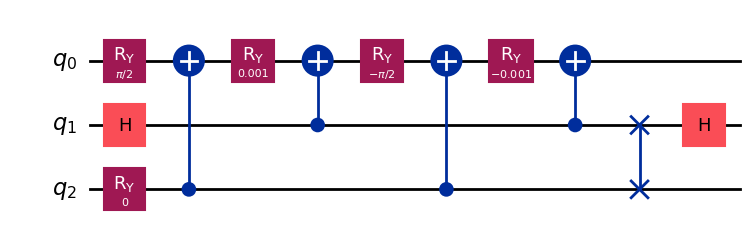

alpha = 1.0
Input-vector norm = 1.0


In [21]:
h = 0.001
omega = 1.0

x0 = 1.0
y0 = 0.0

qc_one_step, alpha, norm_u = (
    create_fable_pendulum_circuit(
        x0,
        y0,
        h,
        omega
    )
)

display(qc_one_step.draw("mpl"))

print("alpha =", alpha)
print("Input-vector norm =", norm_u)

## FABLE one step statevector

The FABLE unitary contains

$$
\frac{M}{2\alpha}
$$

in the branch
$
q_0=0,\qquad q_1=0.
$

Applying the circuit to the normalized input state produces

$$
U_M
\left(
|0\rangle_{q_0}|0\rangle_{q_1}|\psi_n\rangle_{q_2}
\right)
=|0\rangle_{q_0}|0\rangle_{q_1}
\frac{M|\psi_n\rangle}{2\alpha}
+
|\Phi^\perp\rangle,
$$

where $|\Phi^\perp\rangle$ contains all branches in which $q_0$ or
$q_1$ is nonzero.

The extracted successful branch is

$$
|\widetilde{\psi}_{n+1}\rangle
=\frac{M|\psi_n\rangle}{2\alpha}.
$$

Since
$
|\psi_n\rangle=\frac{u_n}{\|u_n\|},
$
we have

$$
|\widetilde{\psi}_{n+1}\rangle
=\frac{Mu_n}{2\alpha\|u_n\|}
=\frac{u_{n+1}}{2\alpha\|u_n\|}.
$$

Therefore, the unnormalized classical output is recovered as

$$
u_{n+1}
=2\alpha\|u_n\|
|\widetilde{\psi}_{n+1}\rangle.
$$

The statevector simulator provides the successful amplitudes directly. On
quantum hardware, these amplitudes would have to be inferred from
measurements, tomography, or an observable-based readout procedure.

In [22]:
def fable_step_statevector(
    x,
    y,
    h,
    omega,
    alpha=None,
    return_details=False
):
    qc, alpha, norm_u = create_fable_pendulum_circuit(
        x,
        y,
        h,
        omega,
        alpha=alpha
    )

    state = Statevector.from_instruction(qc).data

    # Successful branch: q0 = 0 and q1 = 0.
    # q2 remains as the output-system qubit.
    success_branch = np.array([
        state[basis_index(q0=0, q1=0, q2=0)],
        state[basis_index(q0=0, q1=0, q2=1)]
    ], dtype=complex)

    # Recover the unnormalized classical output.
    u_next = 2.0 * alpha * norm_u * success_branch

    u_next = np.real_if_close(u_next)

    x_next = float(np.real(u_next[0]))
    y_next = float(np.real(u_next[1]))

    if return_details:
        success_probability = float(
            np.vdot(success_branch, success_branch).real
        )

        return {
            "x_next": x_next,
            "y_next": y_next,
            "success_branch": success_branch,
            "success_probability": success_probability,
            "alpha": alpha,
            "input_norm": norm_u,
            "circuit": qc
        }

    return x_next, y_next

## Verify one step

In [23]:
h = 0.001
omega = 1.0

x0 = 1.0
y0 = 0.0

# Direct classical Euler step.
x_classical_1 = x0 + h * y0
y_classical_1 = y0 - h * omega**2 * x0

# FABLE step.
step_result = fable_step_statevector(
    x0,
    y0,
    h,
    omega,
    return_details=True
)

x_fable_1 = step_result["x_next"]
y_fable_1 = step_result["y_next"]

one_step_error = np.linalg.norm(
    np.array([x_fable_1, y_fable_1])
    -
    np.array([x_classical_1, y_classical_1])
)

print("Classical Euler step:")
print(x_classical_1, y_classical_1)

print("\nFABLE step:")
print(x_fable_1, y_fable_1)

print("\nSuccessful branch:")
print(
    np.real_if_close(
        step_result["success_branch"]
    )
)

print("\nSuccess probability:")
print(step_result["success_probability"])

print("\nOne-step error:")
print(one_step_error)

Classical Euler step:
1.0 -0.001

FABLE step:
0.9999999999999998 -0.0009999999999999538

Successful branch:
[ 5.e-01 -5.e-04]

Success probability:
0.25000024999999987

One-step error:
2.2679736926254565e-16


## Verify success probablity

In [24]:
u0 = np.array([x0, y0], dtype=float)
M = pendulum_update_matrix(h, omega)

expected_probability = (
    np.linalg.norm(M @ u0)**2
    /
    (
        4.0
        * step_result["alpha"]**2
        * np.linalg.norm(u0)**2
    )
)

print(
    "Statevector success probability:",
    step_result["success_probability"]
)

print(
    "Expected success probability:",
    expected_probability
)

print(
    "Probability error:",
    abs(
        step_result["success_probability"]
        - expected_probability
    )
)

Statevector success probability: 0.25000024999999987
Expected success probability: 0.25000025000000003
Probability error: 1.6653345369377348e-16


## Classical Euler Trajectory

The classical forward-Euler trajectory is used as the reference for the
FABLE calculation. Both procedures apply exactly the same discrete update

$$
u_{n+1}=Mu_n.
$$

Therefore, agreement between them verifies the FABLE implementation. It
does not establish that forward Euler reproduces the exact continuous
pendulum solution without discretization error.

In particular, forward Euler is not energy conserving for the harmonic
oscillator. Any gradual amplitude change shared by both trajectories is a
property of the discretization rather than a FABLE error.

In [25]:
def classical_euler_linear_pendulum(
    h,
    omega,
    x0,
    y0,
    n_steps
):
    x_vals = [x0]
    y_vals = [y0]

    x = x0
    y = y0

    for _ in range(n_steps):
        x_next = x + h * y
        y_next = y - h * omega**2 * x

        x = x_next
        y = y_next

        x_vals.append(x)
        y_vals.append(y)

    t_vals = np.arange(n_steps + 1) * h

    return (
        t_vals,
        np.array(x_vals),
        np.array(y_vals)
    )

## Full trajectory using FABLE

The one-step calculation is repeated to construct the complete trajectory:

$$
u_n
\longrightarrow
\frac{u_n}{\|u_n\|}
\longrightarrow
\frac{Mu_n}{2\alpha\|u_n\|}
\longrightarrow
u_{n+1}.
$$

At every iteration:

1. the current classical vector is normalized;
2. the corresponding quantum state is prepared on $q_2$;
3. the FABLE block-encoding circuit is applied;
4. the $q_0=q_1=0$ branch is extracted; and
5. the output is rescaled by $2\alpha\|u_n\|$.

This is a hybrid iterative verification procedure. The output amplitudes are
extracted classically after every step and used to prepare the next input
state. The notebook therefore does not represent a fully coherent sequence
of $10,000$ applications of the block-encoding unitary.

The procedure is nevertheless useful for verifying that FABLE reproduces
the matrix action at each Euler step. It also exposes the readout and
state-repreparation issue that appears when a quantum state is converted
back into classical data after every time step.

In [26]:
def fable_trajectory_statevector(
    h,
    omega,
    x0,
    y0,
    n_steps,
    alpha=None
):
    x_vals = [x0]
    y_vals = [y0]

    x = x0
    y = y0

    for _ in range(n_steps):
        x, y = fable_step_statevector(
            x,
            y,
            h,
            omega,
            alpha=alpha
        )

        x_vals.append(x)
        y_vals.append(y)

    t_vals = np.arange(n_steps + 1) * h

    return (
        t_vals,
        np.array(x_vals),
        np.array(y_vals)
    )

## Run full trajectory

In [27]:
h = 0.001
omega = np.sqrt(9.8)

x0 = np.pi / 2
y0 = 1.0

n_steps = 10000

t_classical, x_classical, y_classical = (
    classical_euler_linear_pendulum(
        h,
        omega,
        x0,
        y0,
        n_steps
    )
)

t_fable, x_fable, y_fable = (
    fable_trajectory_statevector(
        h,
        omega,
        x0,
        y0,
        n_steps
    )
)

## Plot position trajectory

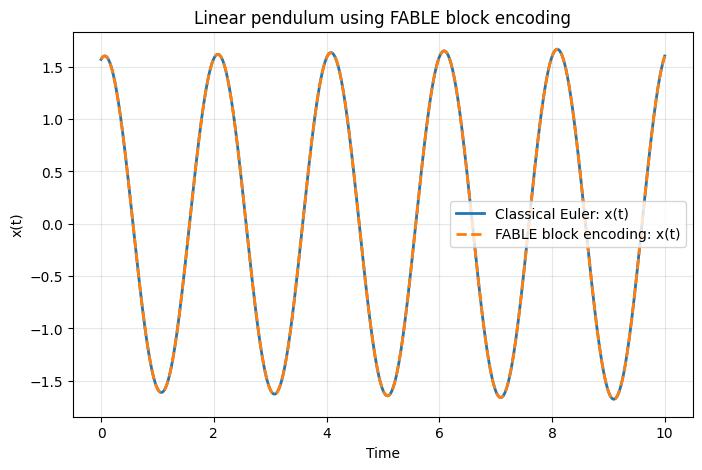

In [28]:
plt.figure(figsize=(8, 5))

plt.plot(
    t_classical,
    x_classical,
    label="Classical Euler: x(t)",
    linewidth=2
)

plt.plot(
    t_fable,
    x_fable,
    "--",
    label="FABLE block encoding: x(t)",
    linewidth=2
)

plt.xlabel("Time")
plt.ylabel("x(t)")
plt.title(
    "Linear pendulum using FABLE block encoding"
)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Plot velocity trajectory

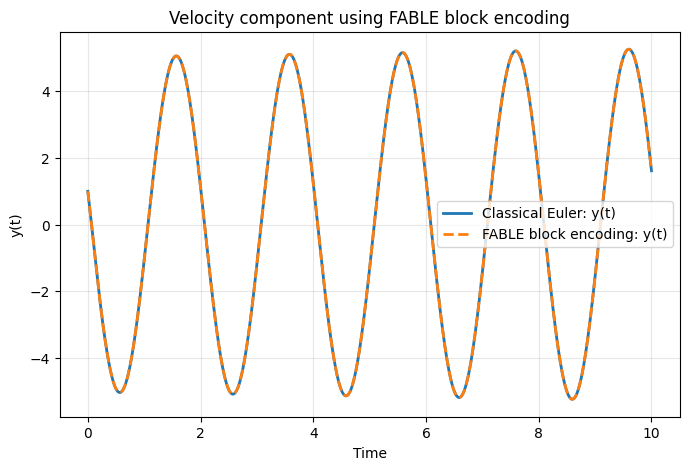

In [29]:
plt.figure(figsize=(8, 5))

plt.plot(
    t_classical,
    y_classical,
    label="Classical Euler: y(t)",
    linewidth=2
)

plt.plot(
    t_fable,
    y_fable,
    "--",
    label="FABLE block encoding: y(t)",
    linewidth=2
)

plt.xlabel("Time")
plt.ylabel("y(t)")
plt.title(
    "Velocity component using FABLE block encoding"
)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Plot trajectory error

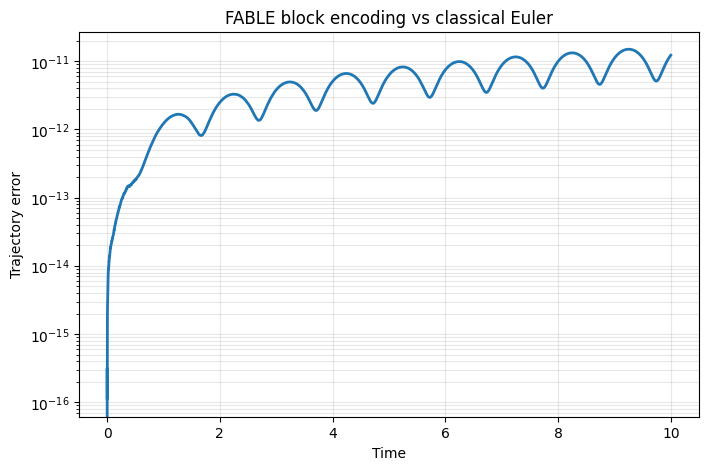

Maximum trajectory error: 1.50184336139424e-11


In [30]:
trajectory_error = np.sqrt(
    (x_fable - x_classical)**2
    +
    (y_fable - y_classical)**2
)

plt.figure(figsize=(8, 5))

plt.plot(
    t_classical,
    trajectory_error,
    linewidth=2
)

plt.yscale("log")
plt.xlabel("Time")
plt.ylabel("Trajectory error")
plt.title(
    "FABLE block encoding vs classical Euler"
)
plt.grid(True, which="both", alpha=0.3)
plt.show()

print(
    "Maximum trajectory error:",
    np.max(trajectory_error)
)

## Comparison with the naive matrix-entry oracle

The naive oracle and FABLE implement the same mathematical mapping:

$$
|0\rangle_a|i\rangle|j\rangle
\longmapsto
\left(
B_{ij}|0\rangle_a
+
\sqrt{1-B_{ij}^2}|1\rangle_a
\right)|i\rangle|j\rangle.
$$

They therefore produce the same encoded block and the same pendulum
trajectory. Their difference lies in how the entry oracle is synthesized.

For an $N\times N$ matrix, where
$
N=2^n,
$
the row and column registers contain $2n$ control qubits in total.

The naive construction uses
$
N^2
$
multi-controlled $R_y$ rotations. Each rotation has $2n$ controls.
Decomposing these gates into elementary one- and two-qubit operations leads,
for a general dense matrix, to an overall scaling of approximately
$
O(N^4).
$

FABLE instead implements a uniformly controlled rotation using
$
N^2
$
ordinary $R_y$ rotations and
$
N^2
$
CNOT gates. Its elementary-gate complexity for a general real dense matrix
is therefore
$
O(N^2).
$

For the $2\times2$ example:

| Method | Rotation structure | Entangling structure |
|---|---:|---:|
| Naive oracle | Four doubly controlled $R_y$ gates | Contained inside their decompositions |
| FABLE | Four ordinary $R_y$ gates | Four CNOT gates |

At this small dimension, both circuits are easy to simulate, and their
numerical outputs are identical. The advantage of FABLE is structural: it
avoids separately decomposing one multi-controlled rotation for every
matrix entry.

The $O(N^2)$ FABLE cost is still exponential in the number of index
qubits because
$
N^2=4^n.
$

This is unavoidable for an arbitrary dense, unstructured matrix containing
$N^2$ independent entries. Further savings are possible when transformed
angles are zero, negligible, or otherwise compressible.

## Exact and approximate FABLE

The word “Approximate” in FABLE refers to an optional circuit-compression
step. After the Walsh-Hadamard/Gray-code transformation, transformed angles
satisfying

$$
|\widehat{\phi}_k|\leq\delta_c
$$

may be set to zero for a chosen cutoff $\delta_c$. Their corresponding
rotation gates can then be removed, and neighboring CNOTs may cancel.

This reduces the circuit size but perturbs the matrix represented by the
encoded block.

In the present notebook,

$$
\delta_c=0,
$$

implicitly: every transformed angle is retained. Therefore,

$$
\epsilon_{\mathrm{compression}}=0,
$$

apart from floating-point round-off. The implementation should more
precisely be described as **exact or uncompressed FABLE**.

A later extension could introduce a nonzero cutoff and study the trade-off
between:

- the number of retained rotations,
- circuit depth,
- block-encoding error, and
- accumulated pendulum-trajectory error.

For the present $2\times2$ example, however, compression is not especially
informative because only four rotation angles are available. Its value
becomes clearer for larger matrices.

## Conclusion

This notebook implemented FABLE block encoding for the forward-Euler update
matrix of the linear pendulum.

The matrix was first scaled as

$$
B=\frac{M}{\alpha},
$$

so that every entry lies in $[-1,1]$. The required matrix-entry rotations
were defined by

$$
\phi_{ij}=2\arccos(B_{ij}).
$$

Rather than applying these angles through separate multi-controlled
rotations, the complete angle vector was transformed as

$$
\widehat{\boldsymbol{\phi}}
=\frac14W_G^T\boldsymbol{\phi}.
$$

The transformed angles were then implemented in a cyclic Gray-code circuit
containing four ordinary $R_y$ rotations and four CNOT gates. The CNOTs
generated different sign patterns for the four row-column basis states,
allowing the shared circuit to reproduce the required entry-dependent
rotations.

The implementation was verified at several levels:

1. the transformed angles reconstructed the original entry angles;
2. each row-column branch reproduced the correct matrix entry;
3. the extracted block agreed with $B/2$;
4. the pendulum circuit reproduced one forward-Euler step;
5. the statevector success probability matched its analytical expression;
   and
6. the full FABLE trajectory agreed with the direct classical Euler
   trajectory.

The maximum difference after $10,000$ steps was approximately
$
1.5\times10^{-11},
$
which is consistent with accumulated floating-point error.

No transformed rotations were discarded, so the present implementation is
an exact, uncompressed FABLE circuit rather than an approximate compressed
one. The principal improvement over the naive oracle is therefore not a
change in the encoded matrix, but a more efficient synthesis of the
matrix-entry oracle using ordinary rotations and CNOT gates.

For a general real dense $N\times N$ matrix, FABLE requires $N^2$
single-qubit rotations and $N^2$ CNOTs, avoiding the expensive
multi-controlled rotations of the naive construction. This provides the
foundation for studying larger matrices, circuit compression, sparse-FABLE
variants, and applications of block encoding within algorithms such as
quantum singular-value transformation.

## References

1. D. Camps and R. Van Beeumen, “FABLE: Fast Approximate Quantum Circuits
   for Block-Encodings,” *2022 IEEE International Conference on Quantum
   Computing and Engineering (QCE)*, 2022.  
   [arXiv:2205.00081](https://arxiv.org/abs/2205.00081)

2. Quantum Computing Lab, “FABLE reference implementations.”  
   [GitHub repository](https://github.com/QuantumComputingLab/fable)